# Quantity Resolution — Visualizations

**The problem:** `4 tbsp Beef` and `4 tbsp Mint Leaves` are wildly different gram weights.

**Pipeline (`quantities.ipynb`):**
1. Parse each quantity string into a `(amount, unit)` pair: `"933g"` → `(933, 'g')`, `"4 tbsp"` → `(4, 'tbsp')`.
2. Look up grams-per-unit for each `(ingredient, unit)` pair in the **USDA SR Legacy** database:
   - Filter to portions that match the needed unit (tablespoon / teaspoon / cup / medium / clove…)
   - Prefer plain/raw descriptions; take median of up to 5 best matches → **Tier: sr_legacy**
3. If USDA has no matching entry, fall back to a **flat generic value** (e.g. 1 tbsp = 15 g) → **Tier: generic**
4. `grams = amount × g_per_unit`; combine with CO₂e (kg/kg) → `co2e_kg`.

These charts expose what came from USDA vs the fallback, which units dominated, and where the generic approximations live.

In [11]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

os.makedirs('figures', exist_ok=True)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

# Three tiers:
#   exact_mass  — qty_unit is 'g' or 'kg'; value is already in grams, no approximation
#   sr_legacy   — USDA SR Legacy scientific portion lookup
#   generic     — flat approximation (tbsp→15 g, medium→100 g, to_taste→5 g, …)
TIER_COLORS = {
    'sr_legacy':  '#2E86AB',
    'exact_mass': '#27AE60',
    'generic':    '#F18F01',
}
TIER_LABELS = {
    'sr_legacy':  'USDA SR Legacy',
    'exact_mass': 'Exact mass (g / kg)',
    'generic':    'Generic fallback',
}

grounded = pd.read_csv('../recipe_ingredients_grounded.csv')
grounded['ingredient_lower'] = grounded['ingredient_name'].str.lower().str.strip()
grounded['tier3'] = np.where(grounded['qty_unit'].isin(['g', 'kg']), 'exact_mass', grounded['usda_tier'])

print(f"Rows   : {len(grounded):,}")
print(f"Recipes: {grounded['recipe_id'].nunique()}")
print(f"Unique ingredients : {grounded['ingredient_lower'].nunique()}")
print(f"\nTier distribution (3-tier):")
print(grounded['tier3'].value_counts().to_string())
print(f"\nUnit distribution:")
print(grounded['qty_unit'].value_counts().to_string())


Rows   : 103,908
Recipes: 9997
Unique ingredients : 58

Tier distribution (3-tier):
tier3
sr_legacy     54981
generic       31030
exact_mass    17897

Unit distribution:
qty_unit
tbsp            32016
count_medium    17948
g               17897
clove            9997
to_taste         9997
ml               8067
tsp              7986


## 1 · USDA Tier Breakdown (Overall)

What share of all recipe-ingredient rows used an actual USDA SR Legacy measurement vs the flat generic fallback?

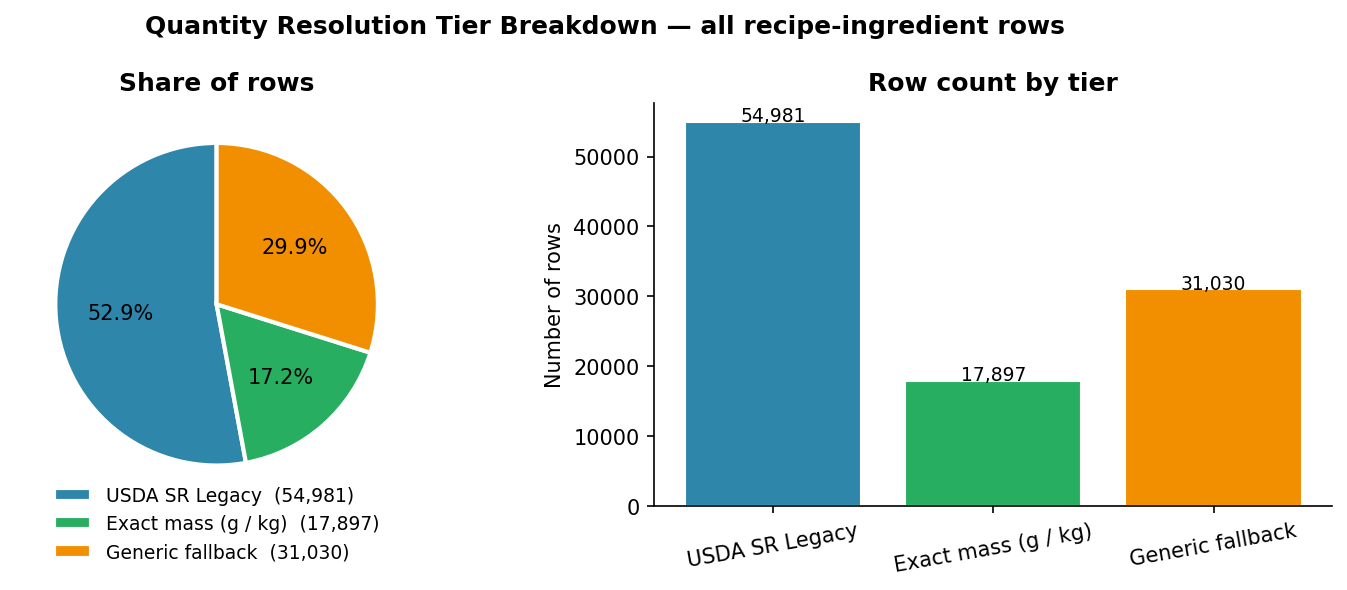

In [12]:

tier_counts = grounded['tier3'].value_counts().reindex(['sr_legacy', 'exact_mass', 'generic']).dropna()
labels = [TIER_LABELS[t] for t in tier_counts.index]
colors = [TIER_COLORS[t] for t in tier_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

wedges, _, autotexts = axes[0].pie(
    tier_counts.values, labels=None, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)
axes[0].legend(wedges, [f"{l}  ({v:,})" for l, v in zip(labels, tier_counts.values)],
               loc='lower center', bbox_to_anchor=(0.5, -0.18), fontsize=9, frameon=False)
axes[0].set_title('Share of rows', fontweight='bold')

axes[1].bar(labels, tier_counts.values, color=colors, edgecolor='white')
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v + 50, f"{v:,}", ha='center', fontsize=9)
axes[1].set_ylabel('Number of rows')
axes[1].set_title('Row count by tier', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(axis='x', rotation=10)

fig.suptitle('Quantity Resolution Tier Breakdown — all recipe-ingredient rows', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/q01_usda_tier_overall.png', bbox_inches='tight')
plt.show()


## 2 · Unit Type Distribution

How often does each parsed unit appear across all recipe-ingredient rows? This shows what unit vocabulary the recipe dataset uses.

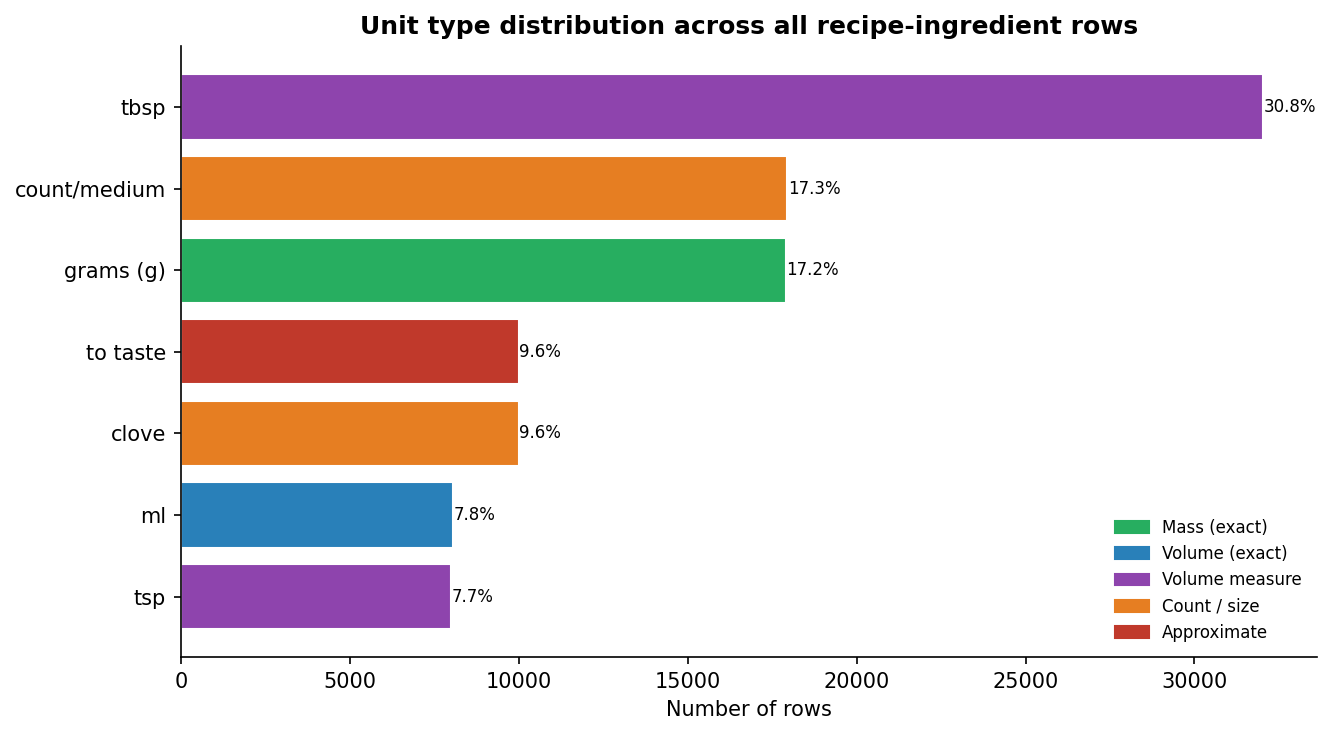

In [3]:
UNIT_LABELS = {
    'tbsp':'tbsp','tsp':'tsp','g':'grams (g)','kg':'kg',
    'ml':'ml','cup':'cup','clove':'clove','count_medium':'count/medium',
    'medium':'medium','large':'large','small':'small',
    'to_taste':'to taste','egg':'egg','fillet':'fillet','other':'other',
}
CAT_COLORS = {
    'Mass (exact)':'#27AE60','Volume (exact)':'#2980B9',
    'Volume measure':'#8E44AD','Count / size':'#E67E22','Approximate':'#C0392B',
}
def unit_cat(u):
    if u in ('g','kg'): return 'Mass (exact)'
    if u == 'ml': return 'Volume (exact)'
    if u == 'to_taste': return 'Approximate'
    if u in ('tbsp','tsp','cup'): return 'Volume measure'
    return 'Count / size'

unit_counts = grounded['qty_unit'].value_counts().reset_index()
unit_counts.columns = ['qty_unit', 'count']
unit_counts['label'] = unit_counts['qty_unit'].map(UNIT_LABELS).fillna(unit_counts['qty_unit'])
unit_counts['category'] = unit_counts['qty_unit'].map(unit_cat)
unit_counts['pct'] = unit_counts['count'] / unit_counts['count'].sum() * 100
unit_counts = unit_counts.sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [CAT_COLORS[c] for c in unit_counts['category']]
bars = ax.barh(unit_counts['label'], unit_counts['count'], color=bar_colors, edgecolor='white')
for bar, pct in zip(bars, unit_counts['pct']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"{pct:.1f}%", va='center', fontsize=8)
ax.set_xlabel('Number of rows')
ax.set_title('Unit type distribution across all recipe-ingredient rows', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

legend_handles = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
ax.legend(handles=legend_handles, fontsize=8, frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig('figures/q02_unit_distribution.png', bbox_inches='tight')
plt.show()


## 3 · USDA Tier by Unit Type

For each unit type, what fraction of rows used USDA SR Legacy vs the generic fallback?  
Units that are exact masses (`g`, `kg`) are always generic (passthrough — no USDA lookup needed). Volume measures (`tbsp`, `tsp`, `cup`) and counts (`medium`, `clove`) may or may not hit USDA.

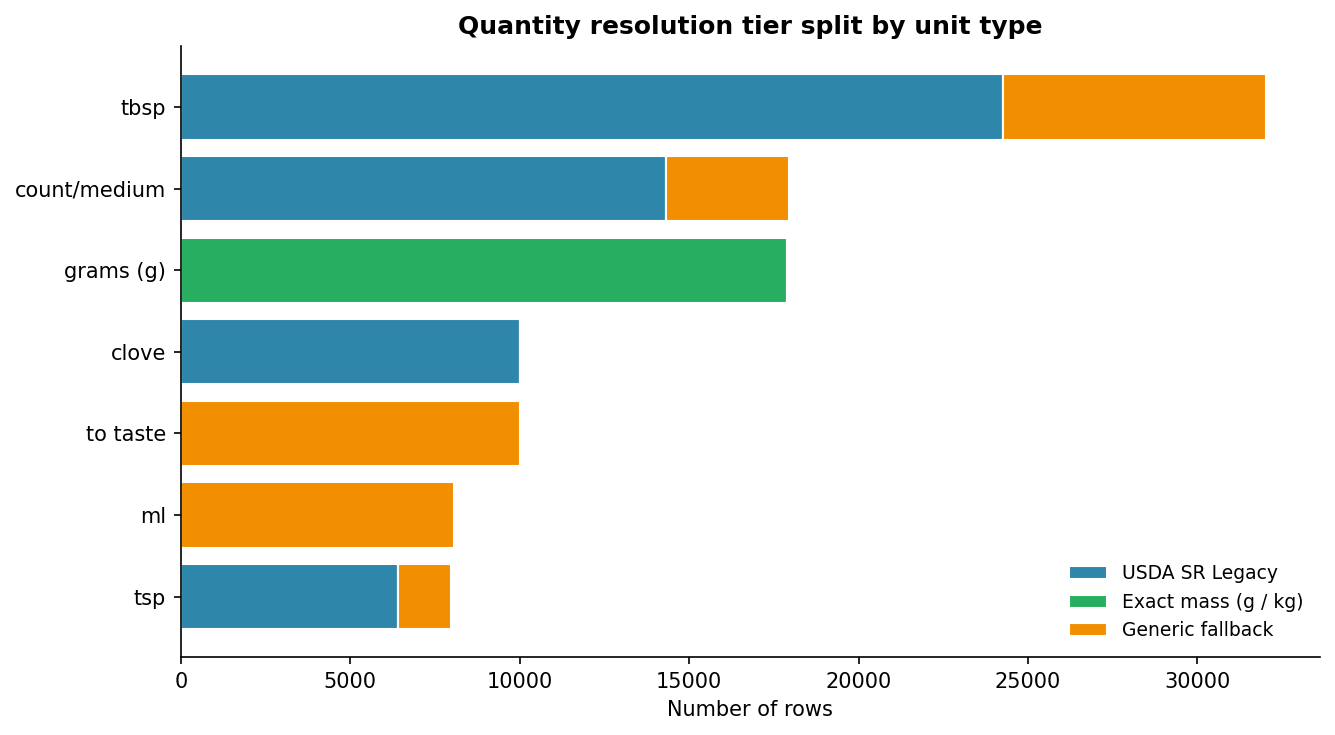

In [13]:

tier_unit = grounded.groupby(['qty_unit', 'tier3']).size().unstack(fill_value=0).reset_index()
tier_unit['total'] = tier_unit.reindex(columns=['sr_legacy','exact_mass','generic'], fill_value=0).sum(axis=1)
tier_unit['label'] = tier_unit['qty_unit'].map(UNIT_LABELS).fillna(tier_unit['qty_unit'])
tier_unit = tier_unit.sort_values('total', ascending=True)

tiers_present = [t for t in ['sr_legacy', 'exact_mass', 'generic'] if t in tier_unit.columns]

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(tier_unit))
for t in tiers_present:
    vals = tier_unit[t].values
    ax.barh(tier_unit['label'], vals, left=bottom,
            color=TIER_COLORS[t], label=TIER_LABELS[t], edgecolor='white')
    bottom += vals

ax.set_xlabel('Number of rows')
ax.set_title('Quantity resolution tier split by unit type', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/q03_tier_by_unit.png', bbox_inches='tight')
plt.show()


## 4 · Per-Ingredient USDA Tier

For each unique ingredient, what tier was used for its gram-weight lookup? Ingredients that always appear in exact mass units (`g`, `kg`) show as generic (passthrough), which is correct.

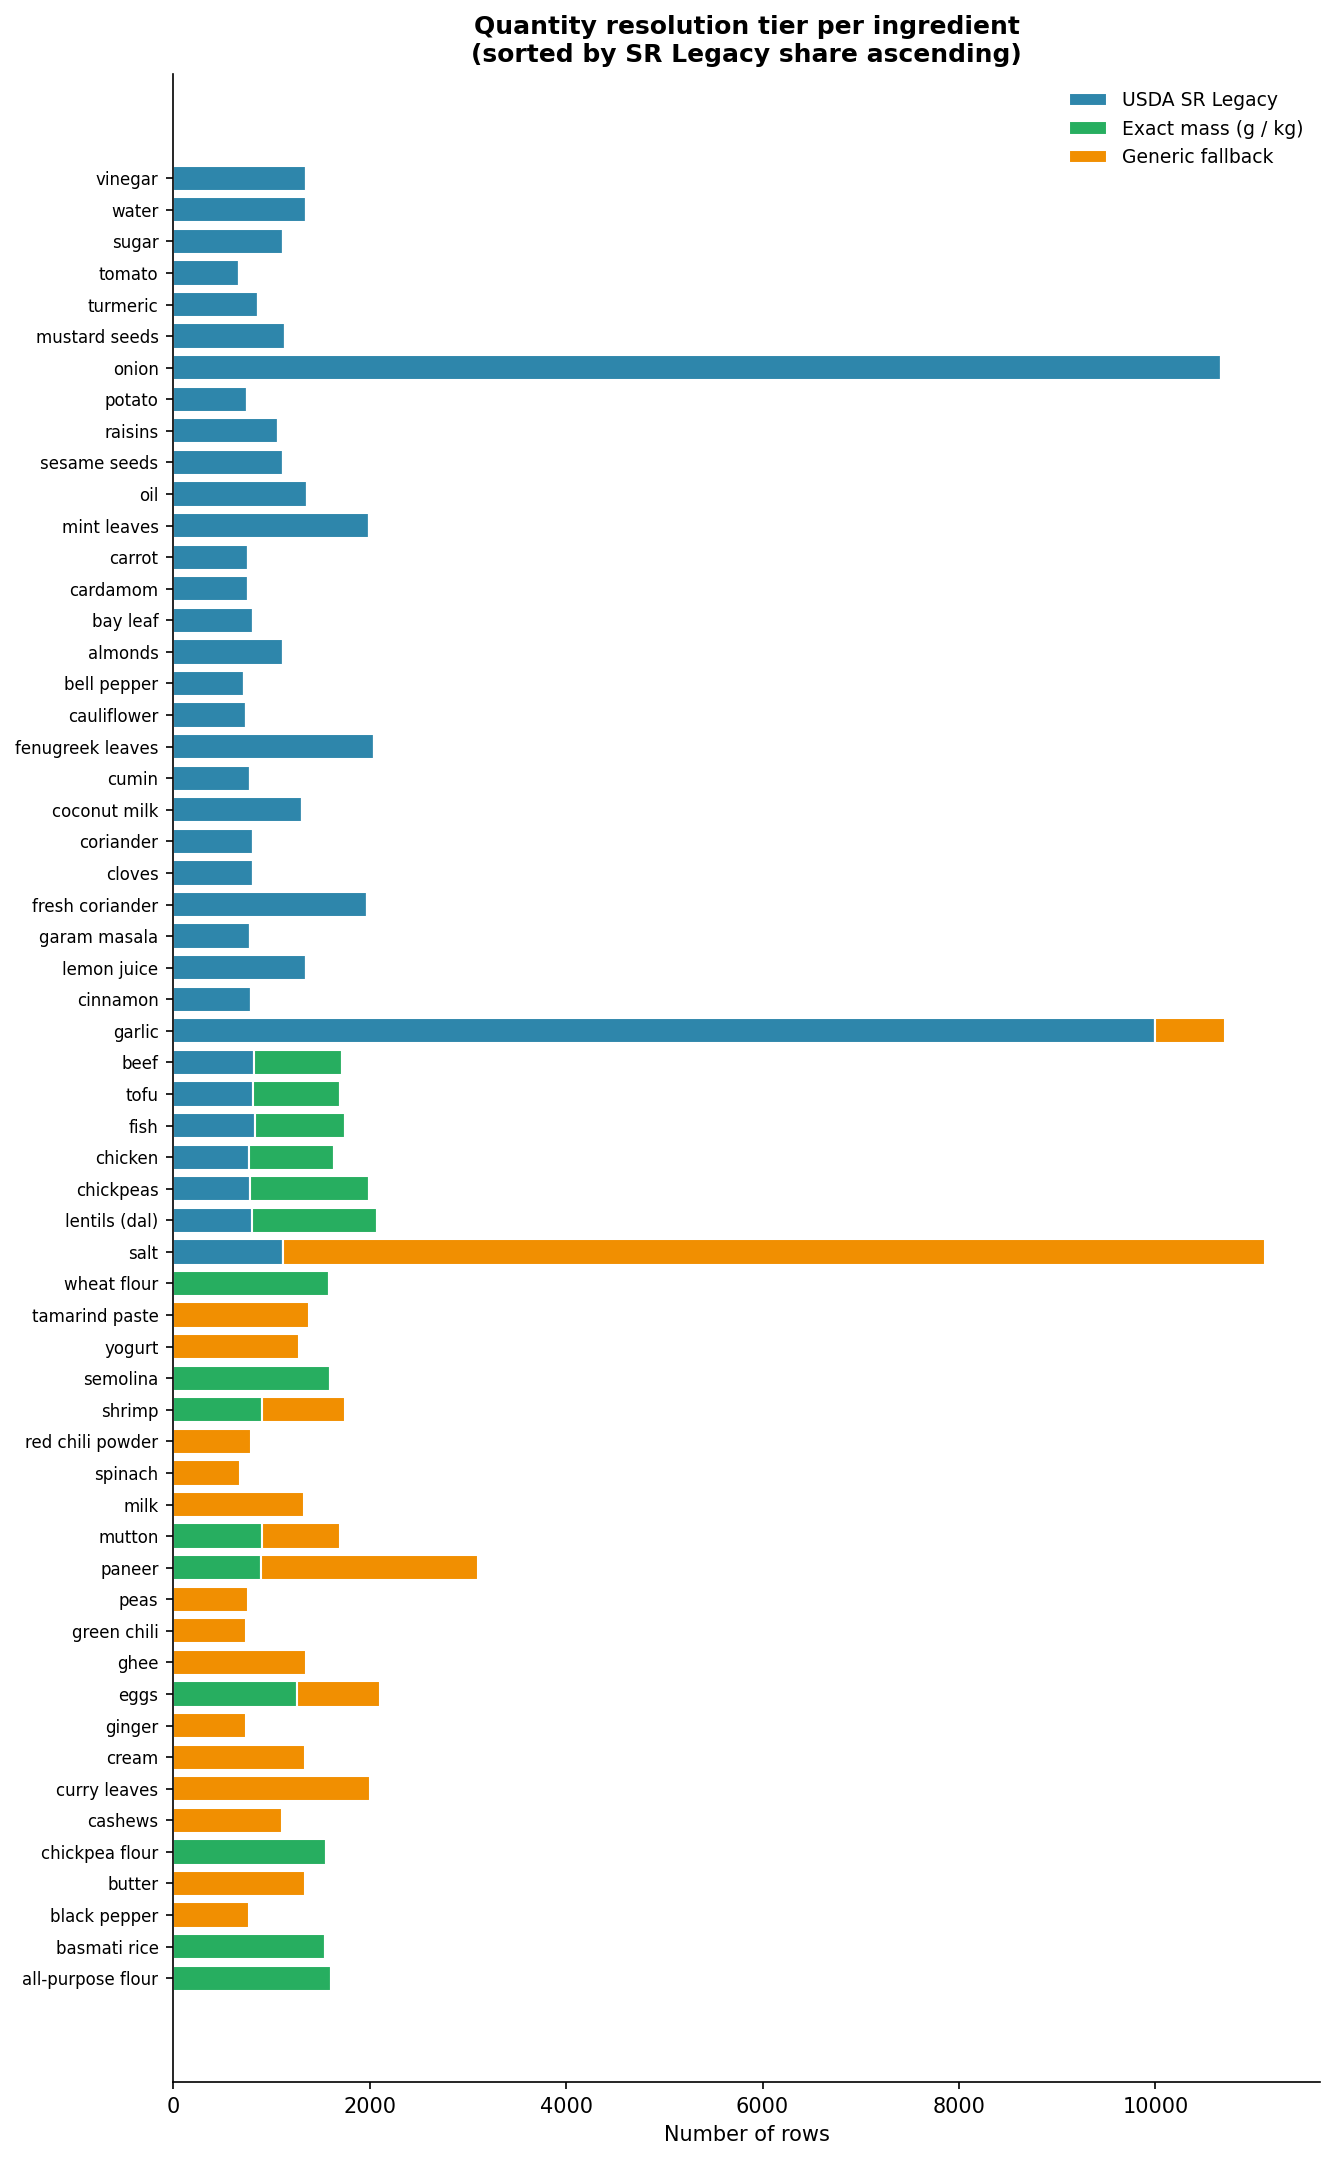

In [14]:

ingr_tier = grounded.groupby(['ingredient_lower', 'tier3']).size().unstack(fill_value=0).reset_index()
ingr_tier['total'] = ingr_tier.reindex(columns=['sr_legacy','exact_mass','generic'], fill_value=0).sum(axis=1)
ingr_tier['sr_pct'] = ingr_tier.get('sr_legacy', 0) / ingr_tier['total'] * 100
ingr_tier = ingr_tier.sort_values('sr_pct', ascending=True)

tiers_present = [t for t in ['sr_legacy', 'exact_mass', 'generic'] if t in ingr_tier.columns]

fig, ax = plt.subplots(figsize=(9, max(6, len(ingr_tier) * 0.25)))
bottom = np.zeros(len(ingr_tier))
for t in tiers_present:
    vals = ingr_tier[t].values
    ax.barh(ingr_tier['ingredient_lower'], vals, left=bottom,
            color=TIER_COLORS[t], label=TIER_LABELS[t], edgecolor='white')
    bottom += vals

ax.set_xlabel('Number of rows')
ax.set_title('Quantity resolution tier per ingredient\n(sorted by SR Legacy share ascending)', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('figures/q04_tier_per_ingredient.png', bbox_inches='tight')
plt.show()


## 5 · USDA Synonym Map

`quantities.ipynb` includes a synonym map that translates recipe ingredient names to the USDA description keywords used for the portion lookup. This table shows every synonym used and the g/unit value that resulted.

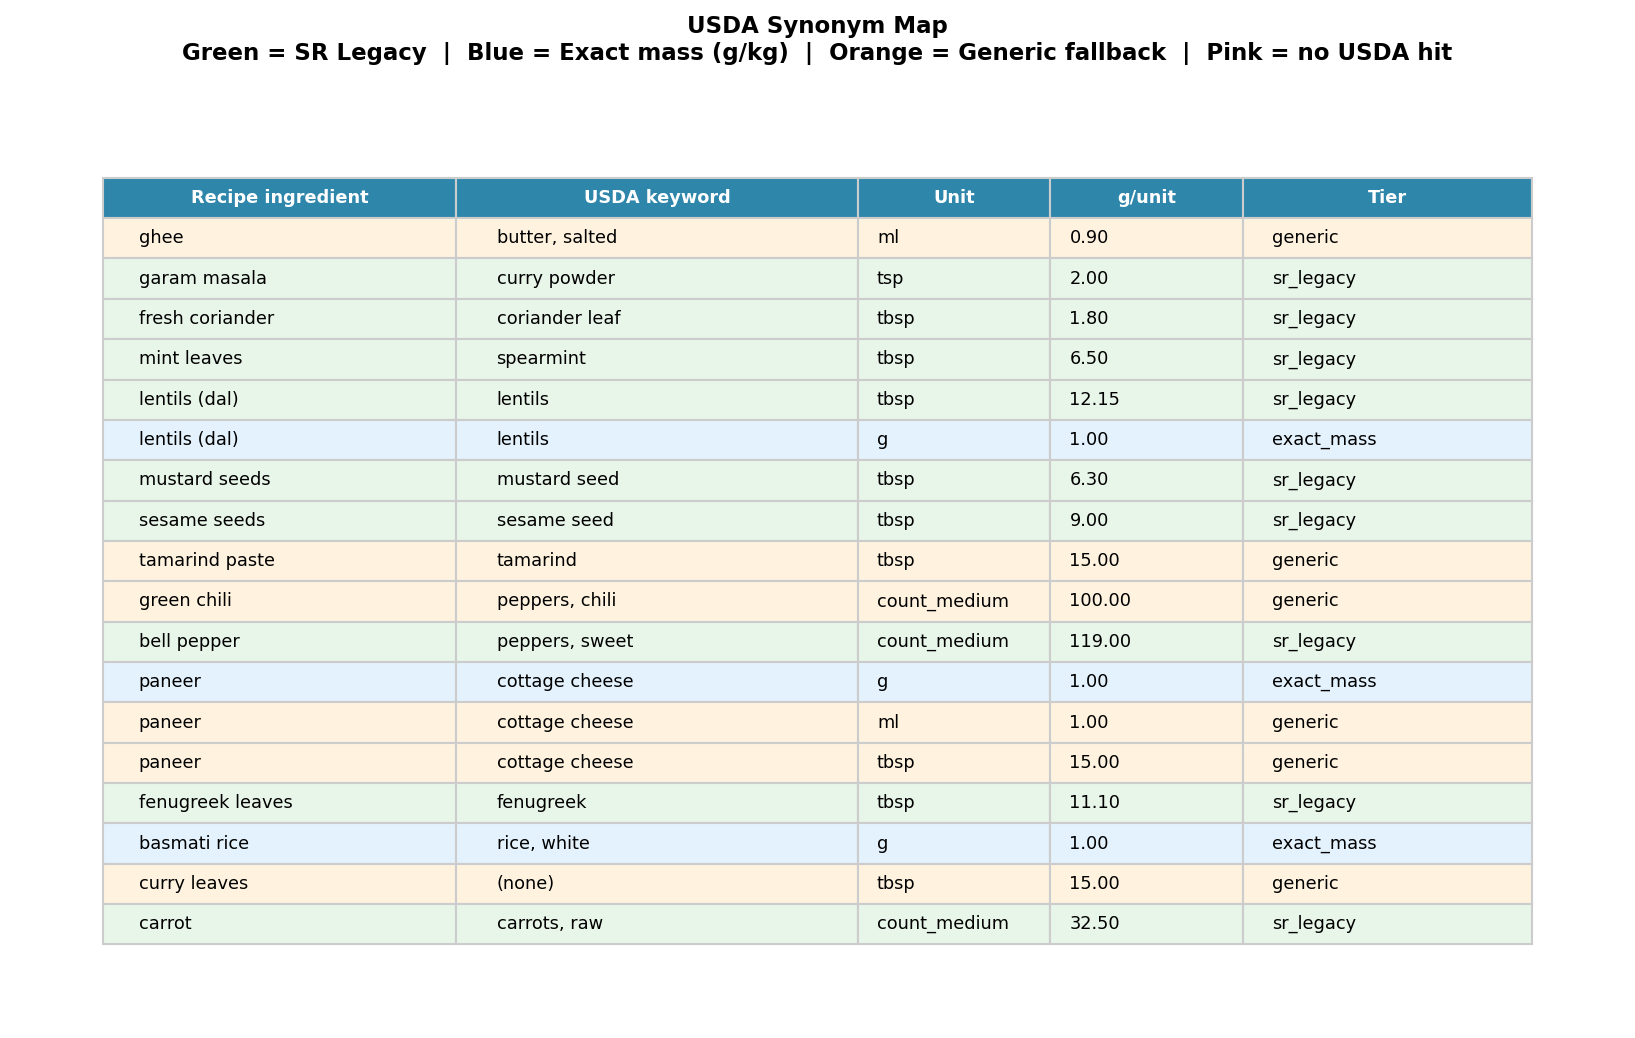

In [15]:

USDA_SYNONYMS = {
    'ghee':'butter, salted','garam masala':'curry powder',
    'fresh coriander':'coriander leaf','mint leaves':'spearmint',
    'lentils (dal)':'lentils','mustard seeds':'mustard seed',
    'sesame seeds':'sesame seed','tamarind paste':'tamarind',
    'green chili':'peppers, chili','bell pepper':'peppers, sweet',
    'paneer':'cottage cheese','fenugreek leaves':'fenugreek',
    'basmati rice':'rice, white','curry leaves':None,'carrot':'carrots, raw',
}

rows = []
for recipe_name, usda_kw in USDA_SYNONYMS.items():
    sub = grounded[grounded['ingredient_lower'] == recipe_name][['qty_unit','g_per_unit','tier3']].drop_duplicates()
    if len(sub) == 0:
        rows.append([recipe_name, usda_kw or '(none)', '—', '—', '—'])
    else:
        for _, r in sub.iterrows():
            rows.append([recipe_name, usda_kw or '(none)', r['qty_unit'],
                         f"{r['g_per_unit']:.2f}", r['tier3']])

syn_df = pd.DataFrame(rows, columns=['Recipe ingredient','USDA keyword','Unit','g/unit','Tier'])

ROW_COLORS = {'sr_legacy': '#E8F5E9', 'exact_mass': '#E3F2FD', 'generic': '#FFF3E0'}

fig, ax = plt.subplots(figsize=(11, max(4, len(syn_df) * 0.33 + 1)))
ax.axis('off')
tbl = ax.table(
    cellText=syn_df.values, colLabels=syn_df.columns,
    cellLoc='left', loc='center',
    colWidths=[0.22, 0.25, 0.12, 0.12, 0.18],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.4)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2E86AB')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        tier = syn_df.iloc[row-1]['Tier'] if row <= len(syn_df) else ''
        cell.set_facecolor(ROW_COLORS.get(tier, '#FCE4EC'))
    cell.set_edgecolor('#CCCCCC')

fig.suptitle(
    'USDA Synonym Map\n'
    'Green = SR Legacy  |  Blue = Exact mass (g/kg)  |  Orange = Generic fallback  |  Pink = no USDA hit',
    fontsize=11, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('figures/q05_usda_synonym_map.png', bbox_inches='tight')
plt.show()


## 6 · Generic Fallback Values

When USDA has no matching portion entry, a flat lookup table is used. This chart shows the flat values and how frequently each was actually invoked.

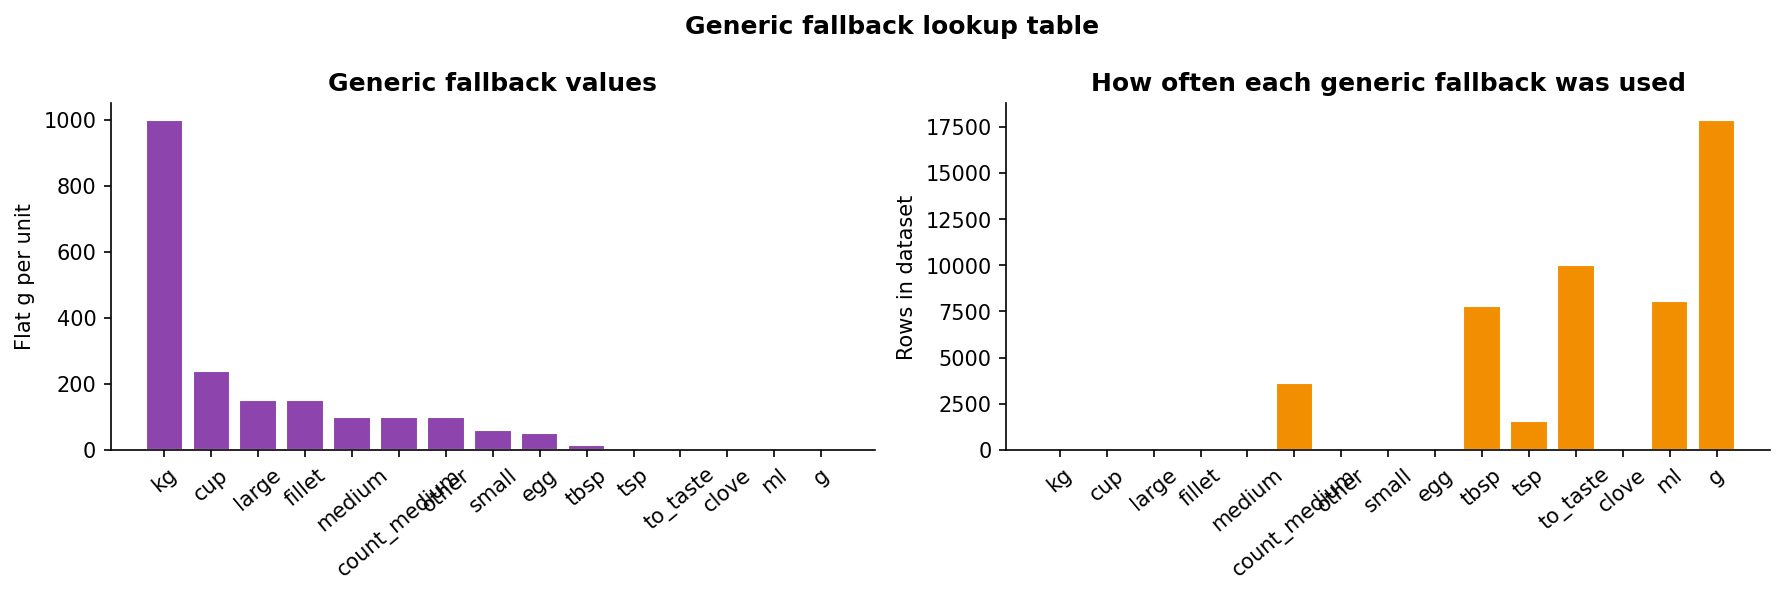

In [7]:
FALLBACK = {
    'tbsp':15.0,'tsp':5.0,'cup':240.0,'ml':1.0,
    'g':1.0,'kg':1000.0,'clove':4.0,
    'medium':100.0,'count_medium':100.0,
    'large':150.0,'small':60.0,
    'to_taste':5.0,'other':100.0,
    'egg':50.0,'fillet':150.0,
}

generic_rows = grounded[grounded['usda_tier'] == 'generic']
unit_usage = generic_rows['qty_unit'].value_counts()

fb_df = pd.DataFrame([
    {'unit': u, 'flat_g': g, 'times_used': int(unit_usage.get(u, 0))}
    for u, g in sorted(FALLBACK.items(), key=lambda x: -x[1])
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(fb_df['unit'], fb_df['flat_g'], color='#8E44AD', edgecolor='white')
axes[0].set_ylabel('Flat g per unit')
axes[0].set_title('Generic fallback values', fontweight='bold')
axes[0].tick_params(axis='x', rotation=40)
axes[0].spines[['top','right']].set_visible(False)

axes[1].bar(fb_df['unit'], fb_df['times_used'], color='#F18F01', edgecolor='white')
axes[1].set_ylabel('Rows in dataset')
axes[1].set_title('How often each generic fallback was used', fontweight='bold')
axes[1].tick_params(axis='x', rotation=40)
axes[1].spines[['top','right']].set_visible(False)

fig.suptitle('Generic fallback lookup table', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/q06_generic_fallback.png', bbox_inches='tight')
plt.show()


## 7 · Grounded g/unit Table — USDA vs Generic

For every `(ingredient, unit)` combination that appears in the dataset, what gram weight was assigned and from which tier? This reveals how different ingredients of the same unit class compare.

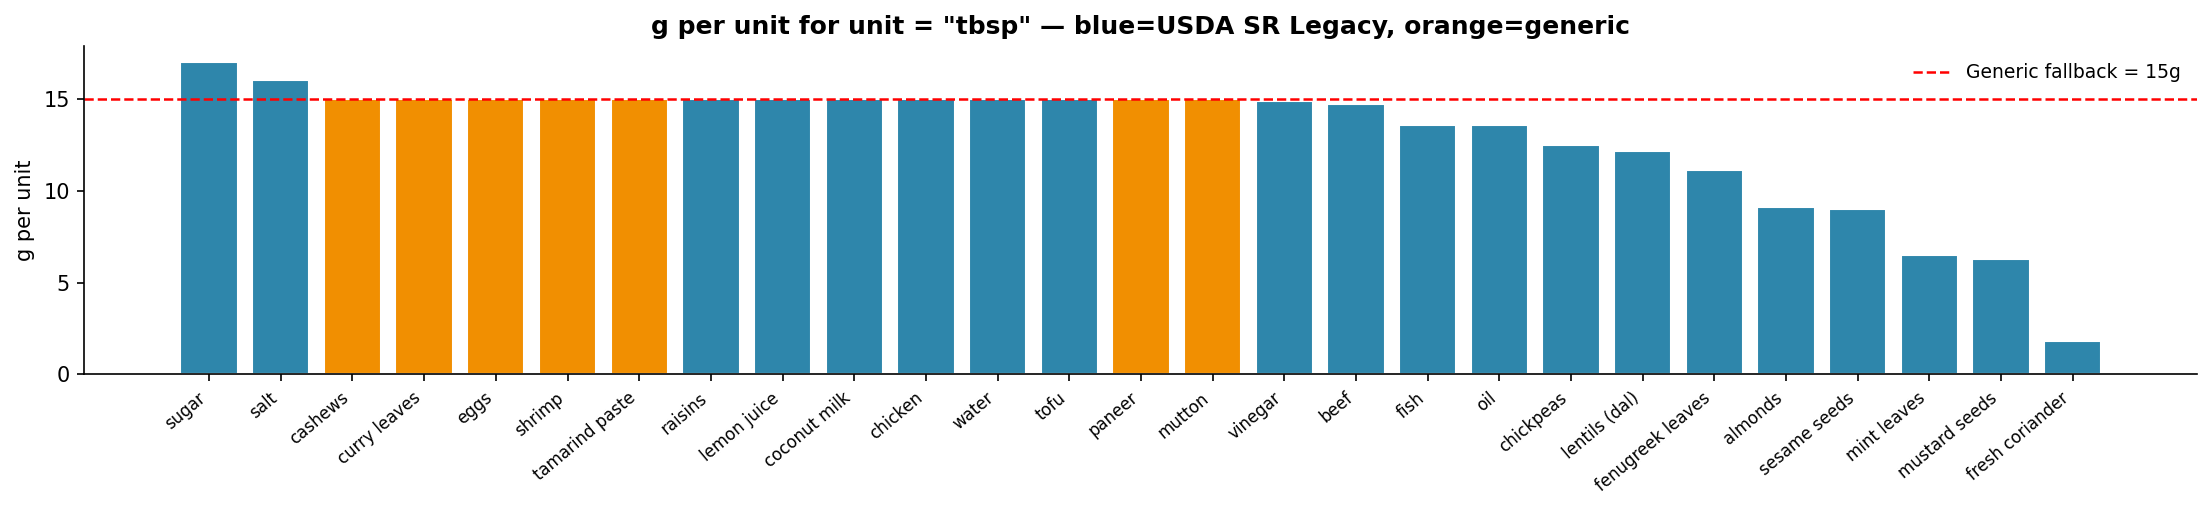

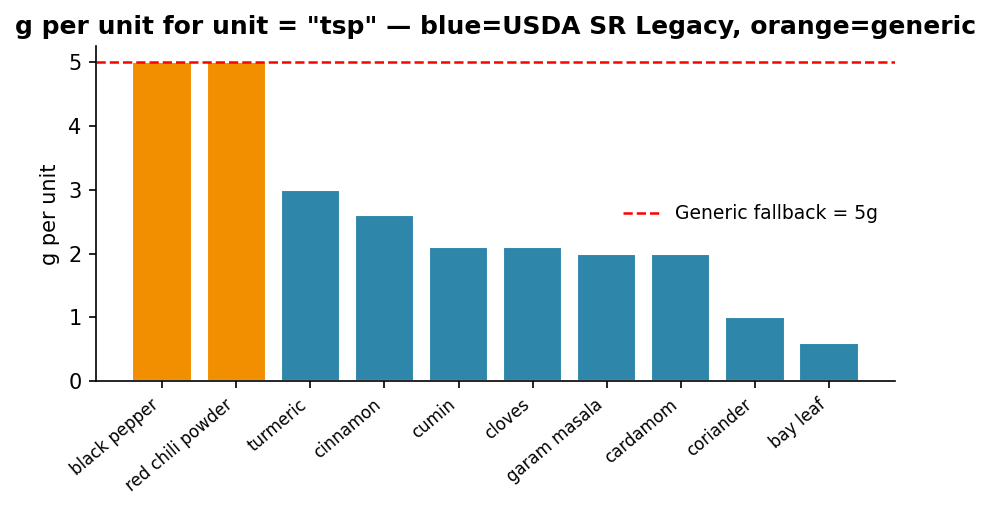

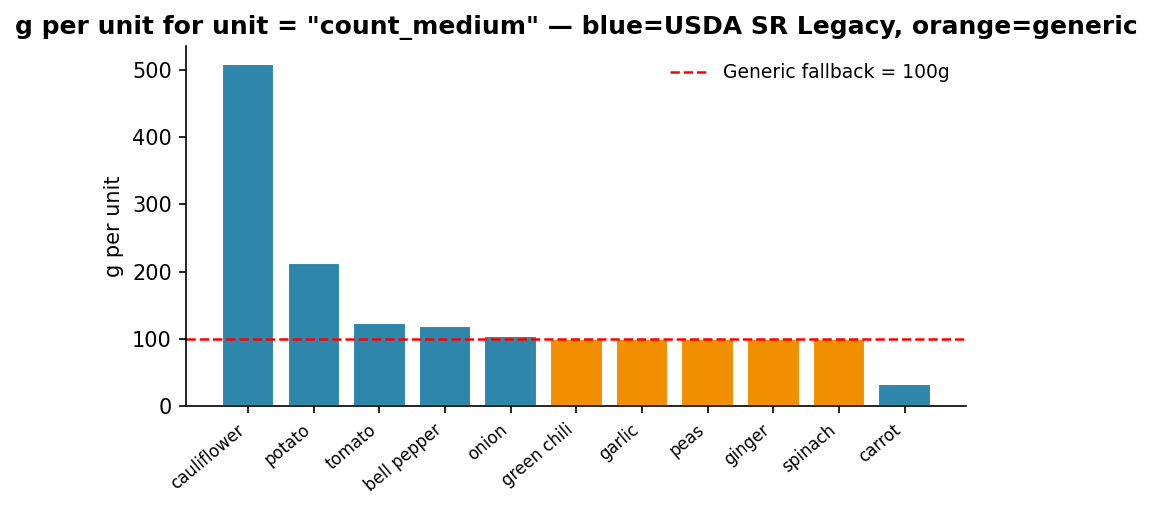

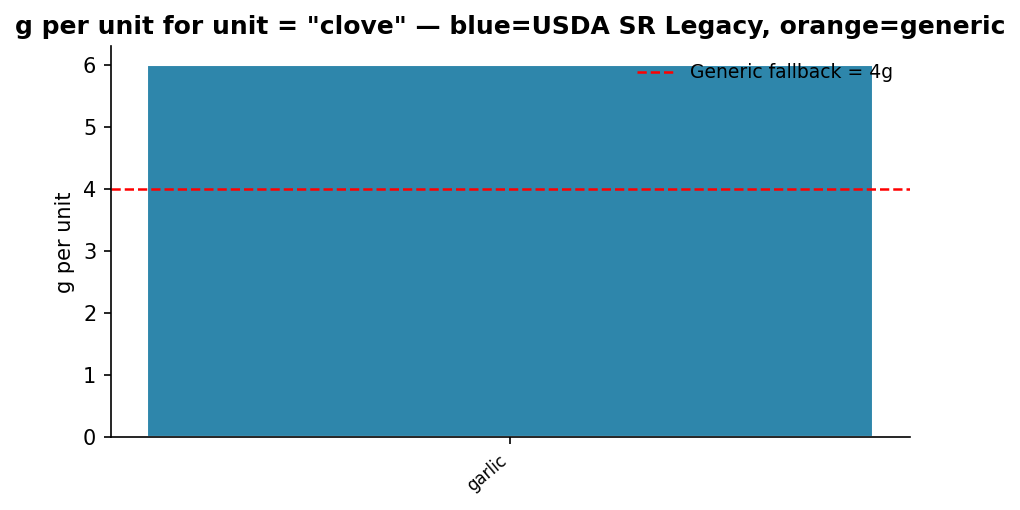

In [8]:
unit_table = (
    grounded.groupby(['ingredient_lower','qty_unit'])
    .agg(g_per_unit=('g_per_unit','first'), tier=('usda_tier','first'))
    .reset_index()
)
non_mass = unit_table[~unit_table['qty_unit'].isin(['g','kg'])].copy()

focus_units = [u for u in ['tbsp','tsp','cup','count_medium','clove','medium','large','small']
               if u in non_mass['qty_unit'].values]

for unit_type in focus_units:
    sub = non_mass[non_mass['qty_unit'] == unit_type].sort_values('g_per_unit', ascending=False)
    if len(sub) == 0:
        continue
    fallback_val = FALLBACK.get(unit_type)
    bar_colors = ['#2E86AB' if t == 'sr_legacy' else '#F18F01' for t in sub['tier']]

    fig, ax = plt.subplots(figsize=(max(6, len(sub) * 0.55), 3.5))
    bars = ax.bar(range(len(sub)), sub['g_per_unit'], color=bar_colors, edgecolor='white')
    if fallback_val is not None:
        ax.axhline(fallback_val, color='red', linestyle='--', linewidth=1.2,
                   label=f'Generic fallback = {fallback_val:.0f}g')
        ax.legend(fontsize=9, frameon=False)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['ingredient_lower'], rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('g per unit')
    ax.set_title(f'g per unit for unit = "{unit_type}" — blue=USDA SR Legacy, orange=generic', fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'figures/q07_grams_{unit_type}.png', bbox_inches='tight')
    plt.show()


## 8 · Per-Recipe USDA Coverage (usda_pct vs generic_pct)

`recipe_co2.csv` stores the final per-recipe USDA SR Legacy coverage. Recipes where most ingredients were given in grams show low SR Legacy % — which is fine, because no lookup was needed.

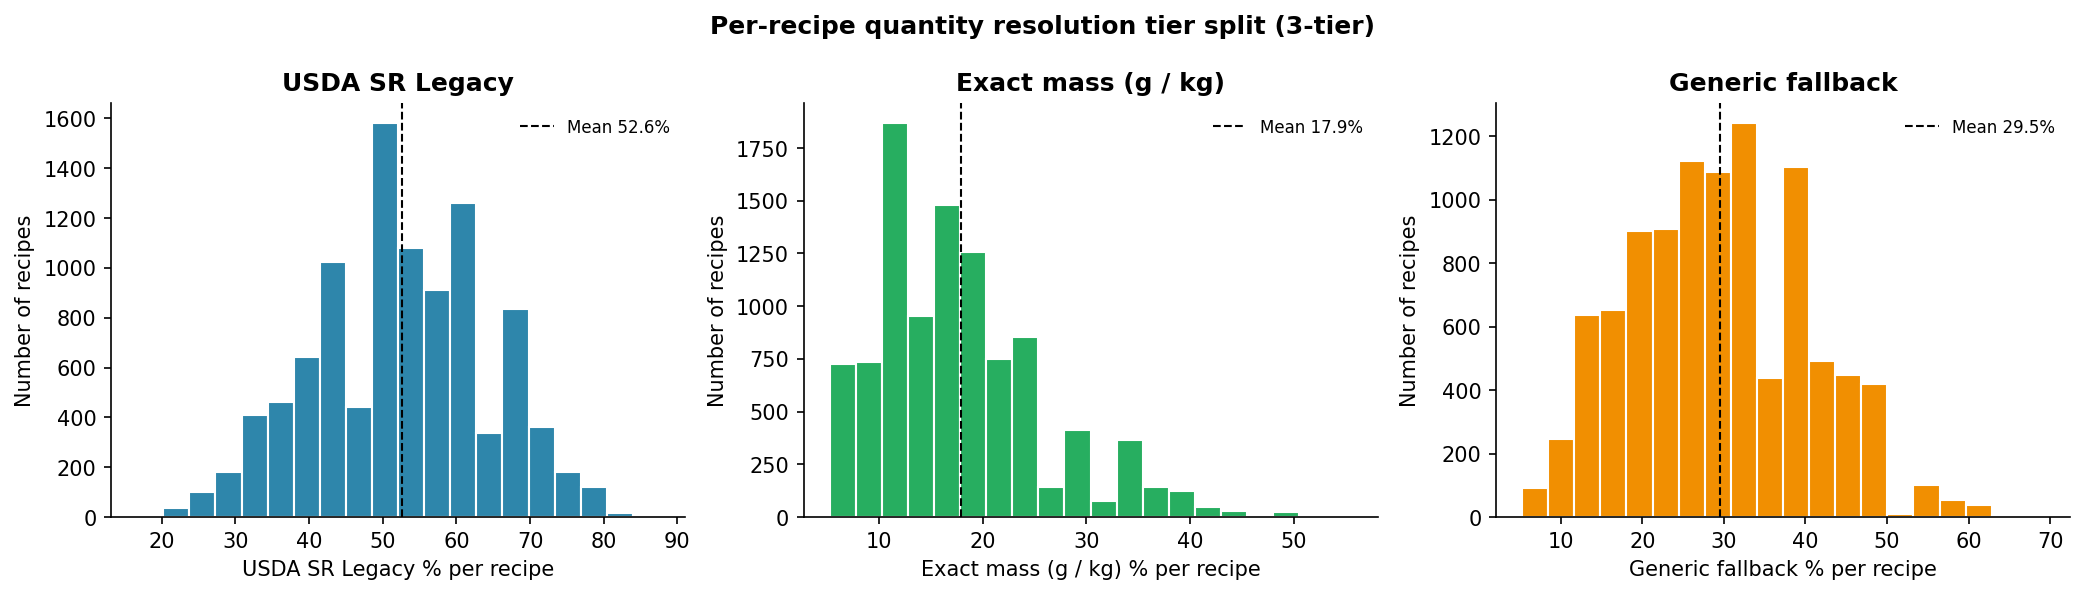

Mean SR Legacy %   : 52.6%
Mean Exact mass %  : 17.9%
Mean Generic %     : 29.5%


In [16]:

# Compute 3-tier coverage per recipe from grounded (using tier3)
recipe_tiers = grounded.groupby(['recipe_id', 'tier3']).size().unstack(fill_value=0).reset_index()
for t in ['sr_legacy', 'exact_mass', 'generic']:
    if t not in recipe_tiers.columns:
        recipe_tiers[t] = 0
recipe_tiers['total'] = recipe_tiers[['sr_legacy', 'exact_mass', 'generic']].sum(axis=1)
for t in ['sr_legacy', 'exact_mass', 'generic']:
    recipe_tiers[f'{t}_pct'] = recipe_tiers[t] / recipe_tiers['total'] * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, t in zip(axes, ['sr_legacy', 'exact_mass', 'generic']):
    ax.hist(recipe_tiers[f'{t}_pct'], bins=20, color=TIER_COLORS[t], edgecolor='white')
    ax.set_xlabel(f'{TIER_LABELS[t]} % per recipe')
    ax.set_ylabel('Number of recipes')
    ax.set_title(TIER_LABELS[t], fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    mean_val = recipe_tiers[f'{t}_pct'].mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1, label=f'Mean {mean_val:.1f}%')
    ax.legend(fontsize=8, frameon=False)

fig.suptitle('Per-recipe quantity resolution tier split (3-tier)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/q08_recipe_usda_coverage.png', bbox_inches='tight')
plt.show()

print(f"Mean SR Legacy %   : {recipe_tiers['sr_legacy_pct'].mean():.1f}%")
print(f"Mean Exact mass %  : {recipe_tiers['exact_mass_pct'].mean():.1f}%")
print(f"Mean Generic %     : {recipe_tiers['generic_pct'].mean():.1f}%")


## 9 · Density Map for ml → grams Conversion

Liquid ingredients given in `ml` bypass USDA and use a density lookup table instead. This chart shows the density values and which ingredients triggered them.

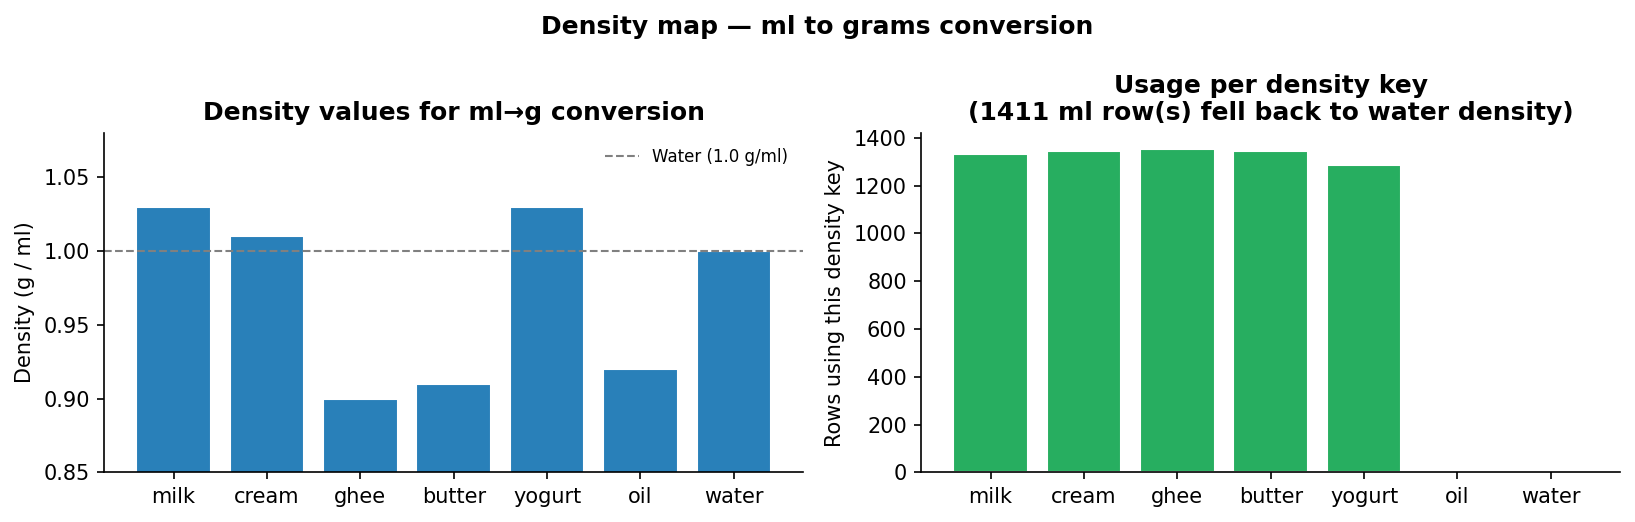

Keyword  g/ml Matched ingredients  Rows
   milk  1.03                milk  1330
  cream  1.01               cream  1344
   ghee  0.90                ghee  1353
 butter  0.91              butter  1343
 yogurt  1.03              yogurt  1286
    oil  0.92   (none in dataset)     0
  water  1.00   (none in dataset)     0


In [10]:
DENSITY = {
    'milk':1.03,'cream':1.01,'ghee':0.90,'butter':0.91,
    'yogurt':1.03,'oil':0.92,'water':1.00,
}

ml_rows = grounded[grounded['qty_unit'] == 'ml']
ml_ingrs = ml_rows['ingredient_lower'].unique()

density_rows = []
for key, density in DENSITY.items():
    matched = [i for i in ml_ingrs if key in i]
    n_rows = int(ml_rows[ml_rows['ingredient_lower'].str.contains(key, na=False)].shape[0])
    density_rows.append({'Keyword': key, 'g/ml': density,
                         'Matched ingredients': ', '.join(matched) or '(none in dataset)',
                         'Rows': n_rows})
density_df = pd.DataFrame(density_rows)

water_fallback = int(ml_rows[~ml_rows['ingredient_lower'].apply(
    lambda x: any(k in x for k in DENSITY)
)].shape[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(density_df['Keyword'], density_df['g/ml'], color='#2980B9', edgecolor='white')
axes[0].axhline(1.0, color='grey', linestyle='--', linewidth=1, label='Water (1.0 g/ml)')
axes[0].set_ylabel('Density (g / ml)')
axes[0].set_title('Density values for ml→g conversion', fontweight='bold')
axes[0].legend(fontsize=8, frameon=False)
axes[0].spines[['top','right']].set_visible(False)
axes[0].set_ylim(0.85, 1.08)

axes[1].bar(density_df['Keyword'], density_df['Rows'], color='#27AE60', edgecolor='white')
axes[1].set_ylabel('Rows using this density key')
axes[1].set_title(f'Usage per density key\n({water_fallback} ml row(s) fell back to water density)',
                  fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

fig.suptitle('Density map — ml to grams conversion', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/q09_density_map.png', bbox_inches='tight')
plt.show()

print(density_df[['Keyword','g/ml','Matched ingredients','Rows']].to_string(index=False))
